   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  

Columns:
Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns 

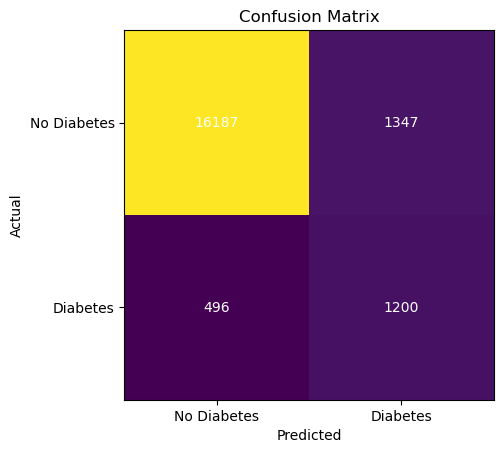


Actual vs Predicted:
    Actual  Predicted
0        0          0
1        0          0
2        0          1
3        0          0
4        0          1
5        0          0
6        0          0
7        0          0
8        0          0
9        0          0
10       0          0
11       0          0
12       0          0
13       0          1
14       0          0
15       0          0
16       1          1
17       0          0
18       0          0
19       0          0

Prediction: No Diabetes
Probability of No Diabetes: 0.9882873492669835
Probability of Diabetes: 0.01171265073301656


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

df = pd.read_csv("diabetes_prediction_dataset.csv")

print(df.head())
print("\nColumns:")
print(df.columns)
print("\nDataset Information:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nNumber of duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

print("\nShape after removing duplicates:", df.shape)
print("\nStatistical Summary:")
print(df.describe())
print("\nDiabetes Class Counts:")
print(df["diabetes"].value_counts())
print("\nDiabetes Class Percentage:")
print(df["diabetes"].value_counts(normalize=True) * 100)

gender_encoder = LabelEncoder()
smoking_encoder = LabelEncoder()

df["gender"] = gender_encoder.fit_transform(df["gender"])
df["smoking_history"] = smoking_encoder.fit_transform(df["smoking_history"])

X = df.drop("diabetes", axis=1)
y = df["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = GaussianNB(var_smoothing=1.0)

model.fit(X_train_scaled, y_train)

probability = model.predict_proba(X_test_scaled)[:, 1]

threshold = 0.10

y_pred = (probability >= threshold).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n----- Model Performance -----")
print("Threshold:", f"{threshold:.4f}")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["No Diabetes", "Diabetes"])
plt.yticks([0, 1], ["No Diabetes", "Diabetes"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white"
        )

plt.show()

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nActual vs Predicted:")
print(results.head(20))

new_patient = pd.DataFrame({
    "gender": ["Female"],
    "age": [45],
    "hypertension": [0],
    "heart_disease": [0],
    "smoking_history": ["never"],
    "bmi": [27.5],
    "HbA1c_level": [5.8],
    "blood_glucose_level": [120]
})

new_patient["gender"] = gender_encoder.transform(new_patient["gender"])
new_patient["smoking_history"] = smoking_encoder.transform(
    new_patient["smoking_history"]
)

new_patient_scaled = scaler.transform(new_patient)

prediction_probability = model.predict_proba(new_patient_scaled)[0][1]

if prediction_probability >= threshold:
    print("\nPrediction: Diabetes")
else:
    print("\nPrediction: No Diabetes")

print("Probability of No Diabetes:", 1 - prediction_probability)
print("Probability of Diabetes:", prediction_probability)



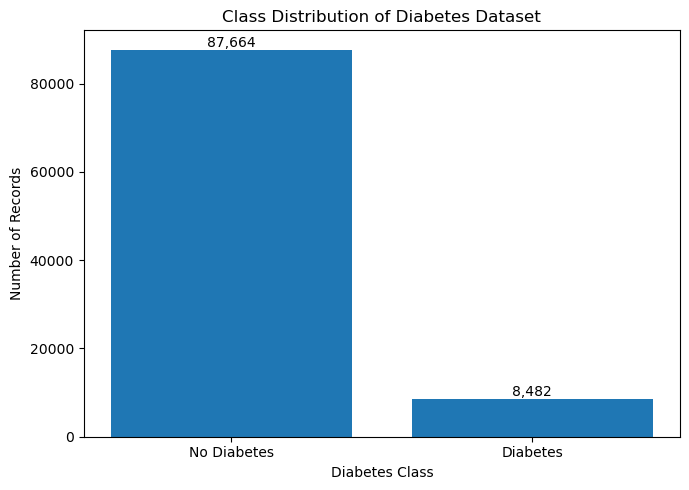